# Cost function optimization landscape

Pennylane tutorial:
https://pennylane.ai/qml/demos/tutorial_local_cost_functions.

## Analytic expression of the global loss function

We precompute the global loss functon under the circuit Ansatz of one layer $Ry(\theta_1)$ and one layer $Rx(\theta_2)$ with parameter $\theta_1, \theta_2\in[-\pi, \pi]$. We have the global loss function given by
\begin{align}C_G(\theta_1, \theta_2)&=1-\left(\cos^{2}\left(\frac{\theta_1}{2}\right)\cos^{2}\left(\frac{\theta_2}{2}\right) + \sin^{2}\left(\frac{\theta_1}{2}\right)\sin^{2}\left(\frac{\theta_2}{2}\right)\right)^{n}\\ &= 1 - \left(\frac{1 + \cos\theta_{1} \cos\theta_{2}}{2} \right)^{n}\end{align}

## Change the cost function to our tilted loss

Here we plot the 2D optimization landscape in a way similar to the tutorial, except for the change of loss function.

Since we focus on the regime when tilting parameter is negative, we define the loss function by 
$$ \mathcal{L}_\gamma(O,\rho(\bm{\theta})) := - \frac{1}{\gamma} \log \text{tr} \!\left( e^{- \gamma O} \rho(\bm{\theta}) \right),$$
so as to make gamma positive. If we consider the 2D optimization landscape with the same circuit Ansatz and, we have the cost function given by
$$\mathcal{L}_\gamma(O_G,\rho(\bm{\theta}))= - \frac{1}{\gamma}  \log\left(1 + (e^{-\gamma}-1)\left[1 - \left(\frac{1 + \cos\theta_{1} \cos\theta_{2}}{2} \right)^{n} \right]\right).$$
Then the optimization landscape is plotted as below.

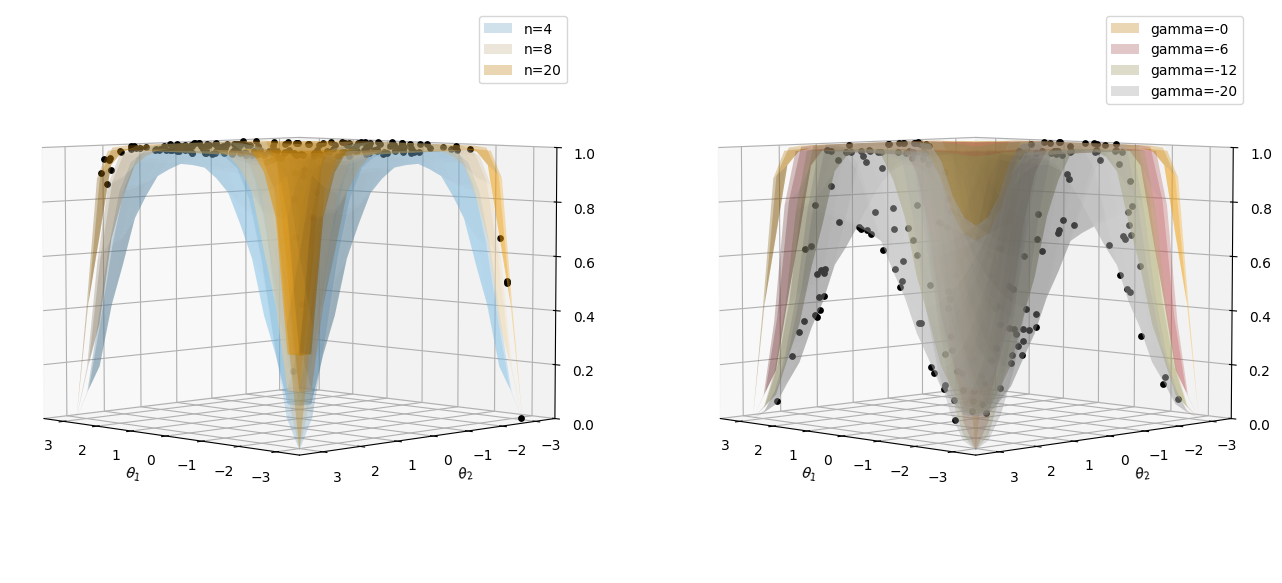

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm

res = 20       # Resolution of the grid
x = np.linspace(-np.pi, np.pi, res)
y = np.linspace(-np.pi, np.pi, res)
X, Y = np.meshgrid(x, y)

def calculate_C_G(n_qubits, theta1, theta2):
    """
    Calculates the value of C_G(theta1, theta2).

    Parameters:
    n_qubits (int or float): The exponent parameter n.
    theta1 (float or np.ndarray): The first angle parameter (theta_1).
    theta2 (float or np.ndarray): The second angle parameter (theta_2).

    Returns:
    float or np.ndarray: The calculated value of C_G.
    """
    # Using the simplified expression: 1 - ((1 + cos(theta1) * cos(theta2)) / 2)^n
    term = (1 + np.cos(theta1) * np.cos(theta2)) / 2
    return 1 - np.power(term, n_qubits)

def calculate_tilted_C_G(n_qubits, theta1, theta2, gamma):
    """
    Calculates the value of tilted loss function.

    Parameters:
    n_qubits (int or float): The exponent parameter n.
    theta1 (float or np.ndarray): The first angle parameter (theta_1).
    theta2 (float or np.ndarray): The second angle parameter (theta_2).
    gamma (float or np.ndarray): tilting parameter.

    Returns:
    float or np.ndarray: The calculated value of tilted C_G.
    """
    # Using the simplified expression: 1 - ((1 + cos(theta1) * cos(theta2)) / 2)^n
    return -(1/gamma) * np.log(1 + (np.exp(-gamma) - 1) * calculate_C_G(n_qubits, theta1, theta2))


def calculate_loss(n_qubits, gamma=0, mode="Orginal"):
    if gamma == 0:
        mode = "Orginal"
    Z = np.zeros((res, res))
    for i in range(res):
        for j in range(res):
            Z[i, j] = calculate_C_G(n_qubits, x[i], y[j]) if mode == 'Orginal' else calculate_tilted_C_G(n_qubits, x[i], y[j], gamma)
    return Z


# Calculate the original landscape with different qubits
Qubits = [4, 8, 20]
# Qubits = [10, 20]
# Qubits = [10]
Z_original = []
for q in Qubits:
    Z_original.append(calculate_loss(q))

# Calculate the tilted loss landscape with different gammas
Gammas = [0, 6, 12, 20]
# Gammas = [10]
Z_tilted = []
n_qubits = 20
for gamma in Gammas:
    Z_tilted.append(calculate_loss(n_qubits, gamma, mode='Tilted'))

# Plotting
fig = plt.figure(figsize=(16, 16))


# Original Cost Plot
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
x_samples = np.random.uniform(-np.pi, np.pi, 200) # Example data
y_samples = np.random.uniform(-np.pi, np.pi, 200) # Example data
z_points = calculate_C_G(n_qubits, x_samples, y_samples)
ax1.scatter(x_samples, y_samples, z_points, color='black', depthshade=False, s=15, zorder=2.01)

colors_qubit = ['lightskyblue', 'moccasin', 'orange']
cmap_choices_qubit = [cm.coolwarm, 'viridis', 'plasma']
transparency_qubit = [0.3, 0.3, 0.3]
for i in range(len(Qubits)):
    q = Qubits[i]
    Z = Z_original[i]
    surf = ax1.plot_surface(X, Y, Z, color=colors_qubit[i], alpha=transparency_qubit[i], label='n='+str(q), zorder=1)

# ax1.set_title(f"Barren Plateau for Different Qubit Number")
ax1.set_xlabel('$\\theta_1$')
ax1.set_ylabel('$\\theta_2$')
ax1.legend(loc='best')
ax1.set_zlim(0, 1)
ax1.view_init(elev=5, azim=135)


# Tilted Cost Plot, small gamma
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
x_samples = np.random.uniform(-np.pi, np.pi, 200) # Example data
y_samples = np.random.uniform(-np.pi, np.pi, 200) # Example data
z_points = calculate_tilted_C_G(n_qubits, x_samples, y_samples, gamma)
ax2.scatter(x_samples, y_samples, z_points, color='black', depthshade=False, s=15, zorder=2.01)

colors_gamma = ['orange', 'indianred', 'darkkhaki', 'silver']
cmap_choices_gamma = ['plasma', cm.coolwarm, 'viridis']
transparency_gamma = [0.3, 0.3, 0.3, 0.3]
for i in range(len(Gammas)):
    gamma = Gammas[i]
    Z = Z_tilted[i]
    surf = ax2.plot_surface(X, Y, Z, color=colors_gamma[i], alpha=transparency_gamma[i], label='gamma=-'+str(gamma), zorder=1)


# ax2.set_title(f"Tilted Loss of $n=20$ for Different Parameters")
ax2.set_xlabel('$\\theta_1$')
ax2.set_ylabel('$\\theta_2$')
ax2.legend(loc='best')
ax2.set_zlim(0, 1)
ax2.view_init(elev=5, azim=135)

# plt.tight_layout()
plt.show()

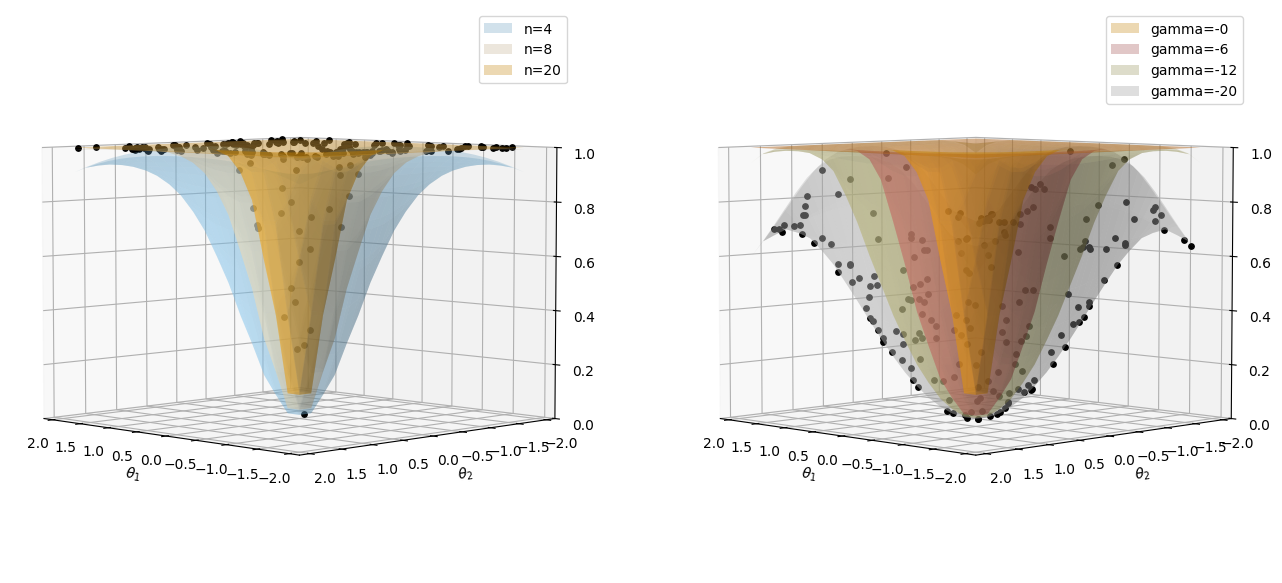

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm

res = 20       # Resolution of the grid
x = np.linspace(-0.6*np.pi, 0.6*np.pi, res)
y = np.linspace(-0.6*np.pi, 0.6*np.pi, res)
X, Y = np.meshgrid(x, y)

def calculate_C_G(n_qubits, theta1, theta2):
    """
    Calculates the value of C_G(theta1, theta2).

    Parameters:
    n_qubits (int or float): The exponent parameter n.
    theta1 (float or np.ndarray): The first angle parameter (theta_1).
    theta2 (float or np.ndarray): The second angle parameter (theta_2).

    Returns:
    float or np.ndarray: The calculated value of C_G.
    """
    # Using the simplified expression: 1 - ((1 + cos(theta1) * cos(theta2)) / 2)^n
    term = (1 + np.cos(theta1) * np.cos(theta2)) / 2
    return 1 - np.power(term, n_qubits)

def calculate_tilted_C_G(n_qubits, theta1, theta2, gamma):
    """
    Calculates the value of tilted loss function.

    Parameters:
    n_qubits (int or float): The exponent parameter n.
    theta1 (float or np.ndarray): The first angle parameter (theta_1).
    theta2 (float or np.ndarray): The second angle parameter (theta_2).
    gamma (float or np.ndarray): tilting parameter.

    Returns:
    float or np.ndarray: The calculated value of tilted C_G.
    """
    # Using the simplified expression: 1 - ((1 + cos(theta1) * cos(theta2)) / 2)^n
    return -(1/gamma) * np.log(1 + (np.exp(-gamma) - 1) * calculate_C_G(n_qubits, theta1, theta2))


def calculate_loss(n_qubits, gamma=None, mode="Orginal"):
    if gamma == 0:
        mode = "Orginal"
    Z = np.zeros((res, res))
    for i in range(res):
        for j in range(res):
            Z[i, j] = calculate_C_G(n_qubits, x[i], y[j]) if mode == 'Orginal' else calculate_tilted_C_G(n_qubits, x[i], y[j], gamma)
    return Z


# Calculate the original landscape with different qubits
Qubits = [4, 8, 20]
# Qubits = [10, 20]
# Qubits = [10]
Z_original = []
for q in Qubits:
    Z_original.append(calculate_loss(q))

# Calculate the tilted loss landscape with different gammas
Gammas = [0, 6, 12, 20]
# Gammas = [10]
Z_tilted = []
n_qubits = 20
for gamma in Gammas:
    Z_tilted.append(calculate_loss(n_qubits, gamma, mode='Tilted'))

# Plotting
fig = plt.figure(figsize=(16, 16))


# Original Cost Plot
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
x_samples = np.random.uniform(-0.6*np.pi, 0.6*np.pi, 200) # Example data
y_samples = np.random.uniform(-0.6*np.pi, 0.6*np.pi, 200) # Example data
z_points = calculate_C_G(n_qubits, x_samples, y_samples)
ax1.scatter(x_samples, y_samples, z_points, color='black', depthshade=False, s=15, zorder=2.01)

colors_qubit = ['lightskyblue', 'moccasin', 'orange']
cmap_choices_qubit = [cm.coolwarm, 'viridis', 'plasma']
transparency_qubit = [0.3, 0.3, 0.3]
for i in range(len(Qubits)):
    q = Qubits[i]
    Z = Z_original[i]
    surf = ax1.plot_surface(X, Y, Z, color=colors_qubit[i], alpha=transparency_qubit[i], label='n='+str(q), zorder=1)

# ax1.set_title(f"Barren Plateau for Different Qubit Number")
ax1.set_xlabel('$\\theta_1$')
ax1.set_ylabel('$\\theta_2$')
ax1.legend(loc='best')
ax1.set_zlim(0, 1)
ax1.view_init(elev=5, azim=135)


# Tilted Cost Plot, small gamma
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
x_samples = np.random.uniform(-0.6*np.pi, 0.6*np.pi, 200) # Example data
y_samples = np.random.uniform(-0.6*np.pi, 0.6*np.pi, 200) # Example data
z_points = calculate_tilted_C_G(n_qubits, x_samples, y_samples, gamma)
ax2.scatter(x_samples, y_samples, z_points, color='black', depthshade=False, s=15, zorder=2.01)

colors_gamma = ['orange', 'indianred', 'darkkhaki', 'silver']
cmap_choices_gamma = ['plasma', cm.coolwarm, 'viridis']
transparency_gamma = [0.3, 0.3, 0.3, 0.3]
for i in range(len(Gammas)):
    gamma = Gammas[i]
    Z = Z_tilted[i]
    surf = ax2.plot_surface(X, Y, Z, color=colors_gamma[i], alpha=transparency_gamma[i], label='gamma=-'+str(gamma), zorder=1)


# ax2.set_title(f"Tilted Loss of $n=20$ for Different Parameters")
ax2.set_xlabel('$\\theta_1$')
ax2.set_ylabel('$\\theta_2$')
ax2.legend(loc='best')
ax2.set_zlim(0, 1)
ax2.view_init(elev=5, azim=135)

# plt.tight_layout()
plt.show()

